In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme()

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score

## Logistic Regression


#### Logistic regression deals with Binary classification (yes/no, 0/1, true/false) problems. It is a linear model for classification rather than regression. The logistic function (sigmoid function) is used to model the probability of a certain class or event existing.

#### Logistic Regression is


#### 2 limitation of Linear regression 
1. Linear regression can predict values outside the range of 0 and 1, which is not suitable for classification problems where the output should be a probability between 0 and 1.
2. Linear regression assumes a linear relationship but the relationship can be non-linear.

##### The sigmoid function

##### The sigmoid (logistic) function is defined as:
##### σ(z) = 1 / (1 + e^(-z))
##### It takes any real number z and maps it to a value between 0 and 1, producing the characteristic S-shaped curve.

#### logistic regression is trained by maximizing the likelihood of the observed labels, 
#### which in practice means minimizing the log loss (also called binary cross-entropy):
#### Loss =  {-[y log(p) + (1-y) log(1-p)]}
#### This loss function penalizes confident wrong predictions heavily and works well with gradient-based optimization, since the sigmoid's smooth, 
#### differentiable shape gives clean gradients for updating the β coefficients.

# Titanic Survival Prediction
This notebook demonstrates a complete machine learning workflow to predict passenger survival on the Titanic using Logistic Regression.

### EDA

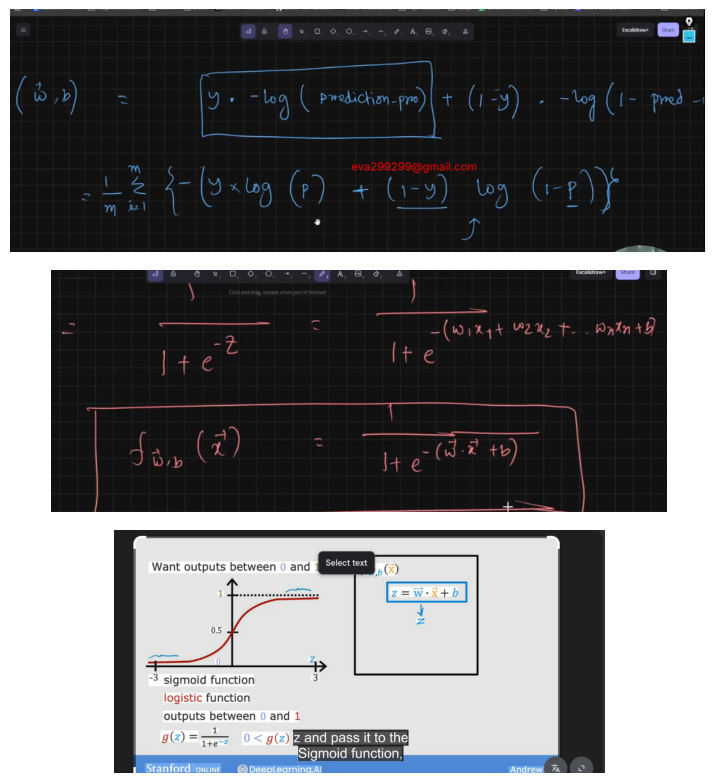

In [5]:
ig, axes = plt.subplots(3, 1, figsize=(8, 8))

for ax, image_path in zip(axes, ['logistic.png', 'logistic2.png', 'logistic3.png']):
    ax.imshow(plt.imread(image_path))
    ax.axis('off')

plt.tight_layout()


In [6]:
df = pd.read_csv("titanic_data.csv")
df.shape


(891, 12)

In [7]:
# checking duplicates
df.duplicated().sum()

df.drop_duplicates(inplace=True)


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [75]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

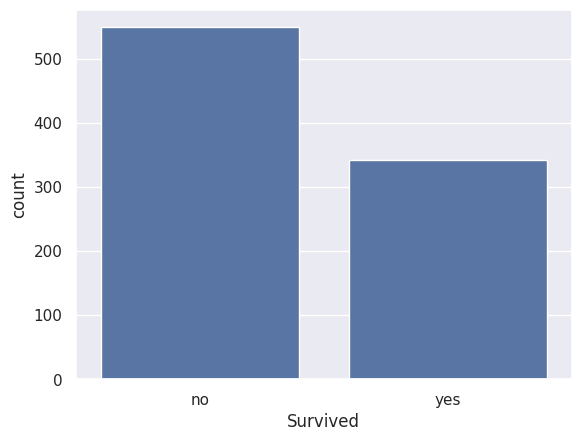

In [76]:
sns.countplot(data = df , x=df['Survived'])

<Axes: xlabel='Pclass', ylabel='count'>

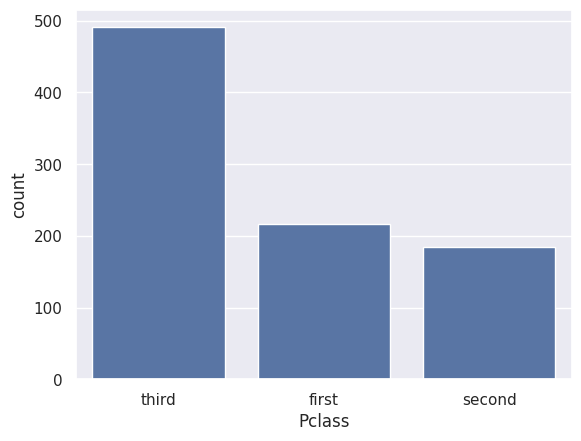

In [77]:
sns.countplot(data = df , x=df['Pclass'])

<Axes: xlabel='Sex', ylabel='count'>

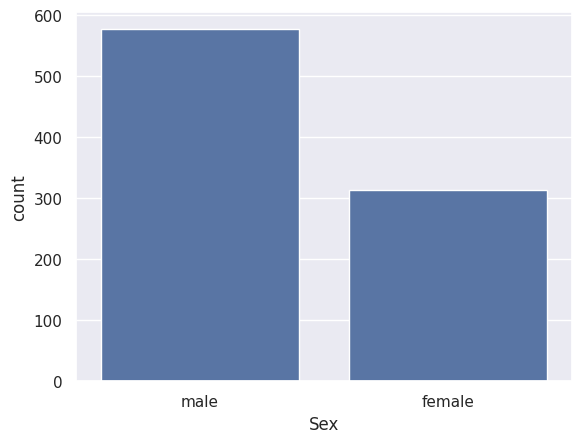

In [78]:
sns.countplot(data = df , x=df['Sex'])

In [79]:
(df['Pclass'].value_counts() / len(df) ) * 100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

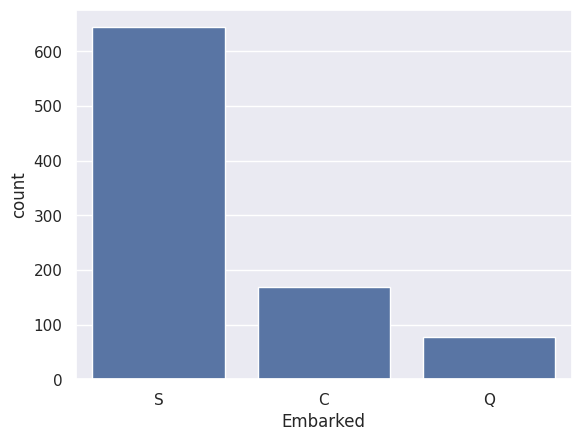

In [80]:
#Embark means the port where the passenger boarded the Titanic. east , #C = Cherbourg, Q = Queenstown, S = Southampton
sns.countplot(data = df , x=df['Embarked'])

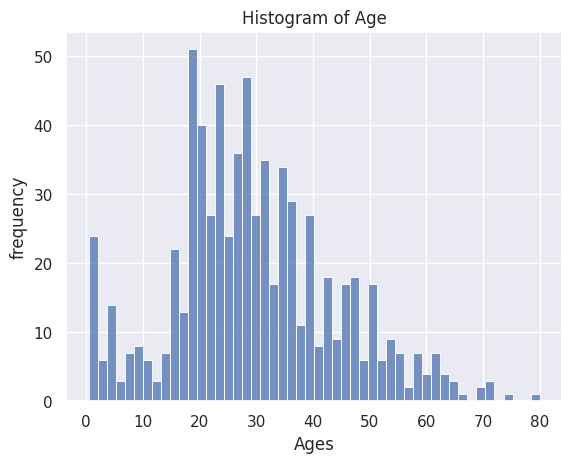

In [81]:
sns.histplot(df['Age'],bins=50)

plt.title('Histogram of Age')
plt.xlabel('Ages')
plt.ylabel('frequency')

plt.show()

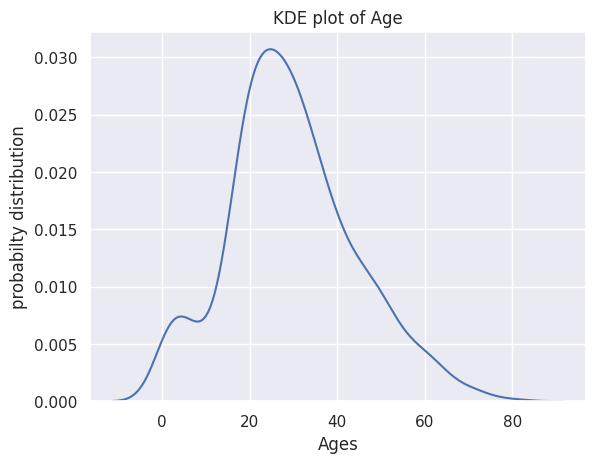

In [82]:
sns.kdeplot(df['Age'])
plt.title('KDE plot of Age')
plt.xlabel('Ages')
plt.ylabel('probabilty distribution')

plt.show()

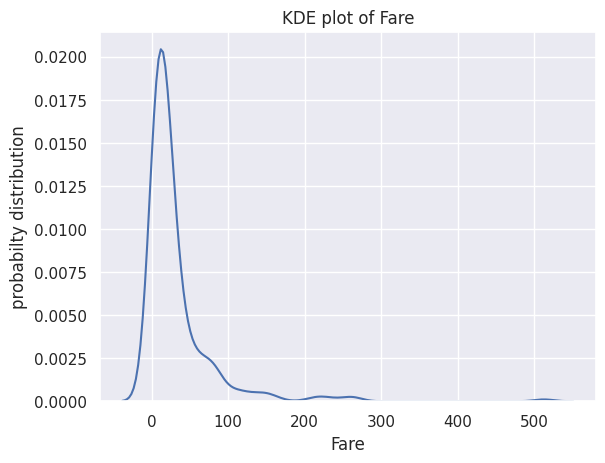

In [83]:
sns.kdeplot(df['Fare'])
plt.title('KDE plot of Fare')
plt.xlabel('Fare')
plt.ylabel('probabilty distribution')

plt.show()

In [10]:
# Feature engineering 
# new features like `Family_Size` and extract the `Deck` from the `Cabin` column to provide more meaningful information to the model.

df['family_size'] = df['SibSp']+ df['Parch'] + 1
df["Cabin"] = df['Cabin'].fillna("Missing")

df['Deck'] = df['Cabin'].astype(str).str[0] # deck A,c,M for missing 
df["Deck"].value_counts()


Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [132]:
df.shape

(891, 14)

In [11]:
X=df.drop('Survived', axis = 1)
y=df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify =y)

# stratify splits train-test on same same ratio og target , (yes/no same ratio)
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)



(712, 13)

(179, 13)

(712,)

(179,)

In [12]:
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)



(712, 13)

(179, 13)

(712,)

(179,)

# Outlier Handling and Data Cleaning
#### We use Z-scores to remove extreme outliers in `Age` and 'clip' the `Fare` column to prevent extreme values from distorting our model's learning.

### Age -> Normal distribution -> use Z-score 
### Fare -> skew distribution -> use IQR method to clip the outliers

### remove outliers using Z-score method

In [146]:
mean= X_train['Age'].mean()
std = X_train['Age'].std()

X_train['Z_score'] = (X_train['Age']-mean) /std

outliners = X_train [abs(X_train['Z_score']) > 3] 

print('Z_SCore Outliers in Age:', len(outliners)) 

print(outliners)


Z_SCore Outliers in Age: 2
     PassengerId Pclass                                  Name   Sex   Age  \
851          852  third                   Svensson, Mr. Johan  male  74.0   
630          631  first  Barkworth, Mr. Algernon Henry Wilson  male  80.0   

     SibSp  Parch  Ticket    Fare    Cabin Embarked  family_size Deck  \
851      0      0  347060   7.775  Missing        S            1    M   
630      0      0   27042  30.000      A23        S            1    A   

      Z_score  
851  3.050857  
630  3.465073  


<Axes: xlabel='Age', ylabel='Density'>

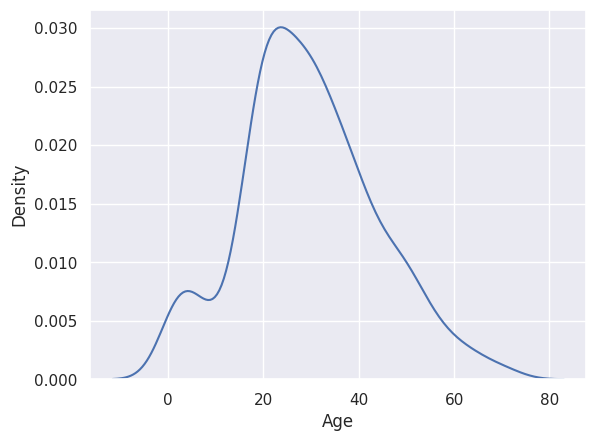

In [129]:
sns.kdeplot(X_train['Age'])

In [128]:
print('total  samples before :', len(X_train))
outliners = X_train [abs(X_train['Z_score']) > 3]  # fix the bug 
X_train= X_train [abs(X_train['Z_score']) <= 3]

print('number of outliers:', len(outliners))
print('number of final samples without outliers:', len(X_train))



total  samples before : 712
number of outliers: 2
number of final samples without outliers: 573


### Clipping Fare 

In [13]:

fare_Q1=X_train['Fare'].quantile(0.25)

fare_Q3=X_train['Fare'].quantile(0.75)

fare_IQR= fare_Q3 - fare_Q1

fare_minimum = max(0, fare_Q1-1.5*fare_IQR)

fare_maximum = fare_Q3 + 1.5*fare_IQR

print(fare_minimum)
print(fare_maximum)



0
65.6563


In [14]:
# fare outliners IQR method is better ( skewed distribution data)
print('total train samples:', len(X_train))

Fare_outliners= X_train[(X_train['Fare']< fare_minimum) | (X_train['Fare'] > fare_maximum)]


print("IQR Outliers in Fare:", len(Fare_outliners))

# instead of droping the 96 outlines , we would clip them 

X_train['Fare'] = X_train['Fare'].clip(lower=fare_minimum, upper=fare_maximum)
X_train['Fare'].describe() # min 0 , max 65 


total train samples: 712
IQR Outliers in Fare: 91


count    712.000000
mean      23.958254
std       20.512921
min        0.000000
25%        7.895800
50%       14.454200
75%       31.000000
max       65.656300
Name: Fare, dtype: float64

In [111]:
df 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Z_score
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,-0.530005
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.571430
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,-0.254646
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.364911
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.364911
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,no,third,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,0.640270
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,-0.185807
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,-0.736524
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,-0.254646


In [158]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         2
family_size      0
Deck             0
dtype: int64

DROP entirely (useless for modeling):

  PassengerId  

  Name        

  Ticket 

  Cabin   
       
NUMERICAL columns:
  Age          → float, has nulls (177 missing)

  Fare         → float, no nulls

  SibSp        → int, no nulls

  Parch        → int, no nulls

CATEGORICAL columns:
  Survived     → target, don't touch

  Pclass       → ordinal (1 > 2 > 3), stored as object

  Sex          → binary nominal

  Embarked     → nominal 3 classes, 2 nulls

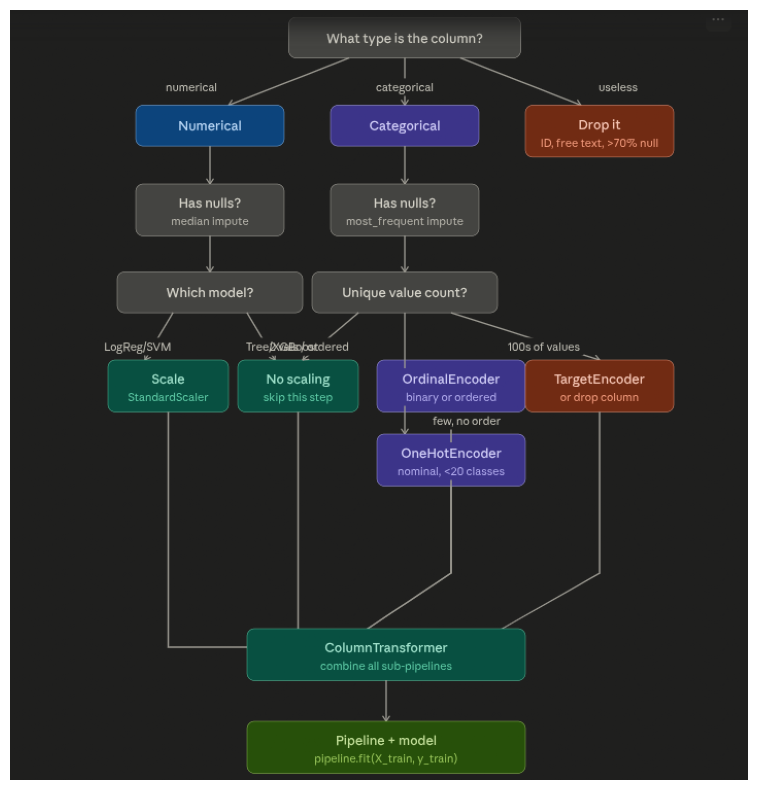

In [92]:
image = plt.imread('pipeline.png')

plt.figure(figsize=(20, 10))  

plt.imshow(image)
plt.axis('off')
plt.show()

In [160]:
display(X_train.shape)
display(X_test.shape)
display(y_train.shape)
display(y_test.shape)
X_train.info()



(712, 13)

(179, 13)

(712,)

(179,)

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    object 
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        712 non-null    object 
 10  Embarked     710 non-null    object 
 11  family_size  712 non-null    int64  
 12  Deck         712 non-null    object 
dtypes: float64(2), int64(4), object(7)
memory usage: 77.9+ KB


##  Building Preprocessing Pipelines


#### useless coloumns are passengerid, name, ticket, cabin , SibSp, Parch

#### numerical features are age , fare , family_size

#### Categorical features are Pclass, Sex, Embarked,Deck 



In [77]:
# Numerical features are age , fare , family_size
# 'age' is missing so use imputer , 
# 'Fare' has high values , so scale them using StandardScaler
# 'Fare' outliners are clipped (no outliers), so use StandardScale
# if 'fare' had outlinres , use RobustScaler instead of StandardScaler

p1 = Pipeline(steps =[
    ('imputer' , SimpleImputer(strategy = 'mean') ), # for age , normal distribution curve 
    ('scaler' , StandardScaler())
])


p2 = Pipeline(steps =[
    ('imputer' , SimpleImputer(strategy = 'median') ),  # for fare and family size , skewed  curve
     ('scaler' , StandardScaler())
])

p1
p2

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [28]:
categories =[['third' , 'second' , 'first']]

In [78]:
# for categorical values , Pclass, Sex, Embarked,Deck 
# Pclass is ordinal so Ordinal Encoder , Sex, Embarked, Deck are nominal so OneHotEncoder
# Ordinal [low, medium, high] → [0, 1, 2] 


p3 = Pipeline(steps = [
           ("imputer" , SimpleImputer(strategy = 'most_frequent')) ,
           ("encoding" , OneHotEncoder(sparse_output = False , drop ='first' , handle_unknown = 'ignore') )   
 ]
            )

p4 = Pipeline(steps = [
       ('imputer' , SimpleImputer(strategy = 'most_frequent')) ,
       ('encoding' , OrdinalEncoder(categories = categories ))
])

p3
p4

,steps,"[('imputer', ...), ('encoding', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,"[['third', 'second', ...]]"


In [79]:
preprocessor = ColumnTransformer (
    transformers = [
    ('pipeline_1' , p1, ['Age']) ,
    ('pipeline_2' , p2 , ['Fare' , 'family_size']) ,
    ('pipeline_3' , p3 , ['Embarked' ,'Sex' ,'Deck']) ,
    ('pipeline_4' , p4 , ['Pclass'])
     
] , 
     remainder = 'drop' # drop other columns 
 )

preprocessor

,transformers,"[('pipeline_1', ...), ('pipeline_2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


## Label Encoding 

target column is Survived yes/No -> (0,1) 

In [68]:
le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test) # returns a 2D array

y_test

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

## Model Traing 

In [80]:
lr_model = Pipeline(
    steps=[
        ('preprocessor' , preprocessor) ,
        ('model' , LogisticRegression( class_weight = 'balanced' ,  max_iter =10000)) # balanced like yes/ no equal weight 
    ]
)

lr_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('pipeline_1', ...), ('pipeline_2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
lr_model.fit(X_train , y_train )

lr_model['model'].coef_
lr_model['model'].intercept_
lr_model['model'].classes_

array([0, 1])

# Prediction 

In [87]:
y_pred = lr_model.predict(X_test)

y_pred # 0 for not survived , 1 for survived

lr_model.predict_proba(X_test) # probability scores (0.85 chance of death, 0.15 chance of survival)

array([[8.58734461e-01, 1.41265539e-01],
       [9.24121994e-01, 7.58780064e-02],
       [7.56333448e-01, 2.43666552e-01],
       [9.34744841e-01, 6.52551588e-02],
       [2.29782526e-01, 7.70217474e-01],
       [4.01761843e-01, 5.98238157e-01],
       [2.41872783e-01, 7.58127217e-01],
       [6.35854954e-01, 3.64145046e-01],
       [3.37751732e-01, 6.62248268e-01],
       [7.94259364e-01, 2.05740636e-01],
       [7.74572171e-01, 2.25427829e-01],
       [8.31013383e-01, 1.68986617e-01],
       [3.01761820e-01, 6.98238180e-01],
       [7.08687763e-01, 2.91312237e-01],
       [3.18706469e-02, 9.68129353e-01],
       [7.39240006e-01, 2.60759994e-01],
       [4.88481306e-01, 5.11518694e-01],
       [8.61286832e-01, 1.38713168e-01],
       [7.90782747e-01, 2.09217253e-01],
       [2.27498168e-01, 7.72501832e-01],
       [8.61286832e-01, 1.38713168e-01],
       [1.99838011e-01, 8.00161989e-01],
       [8.62203924e-01, 1.37796076e-01],
       [4.40034235e-01, 5.59965765e-01],
       [8.577552

In [ ]:
accuracy = accuracy_score(y_test , y_pred)
print('Accuracy:', accuracy) # like 75 % accuracy 
precision = precision_score(y_test , y_pred)
print('Precision:', precision)
recall = recall_score(y_test , y_pred)
print('Recall:', recall)

Accuracy: 0.7486033519553073
Precision: 0.65
Recall: 0.7536231884057971


### precision = TP / (TP + FP) -> how many of the predicted positive are actually positive
### Out of everyone I predicted as survived, how many actually survived?"

### Recall = TP / (TP + FN) -> how many of the actual positive are predicted positive
### Out of everyone who actually survived, how many did I predict as survived?"

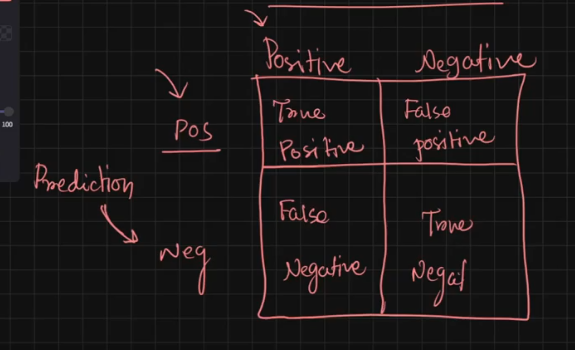

In [92]:
from PIL import Image

img = Image.open("confision_matrix.png")
img